
# GVH Diagonal Cubic — RACC-C.4 REAL
## GW150914 H1/L1 — Real Two-Observer Observation Robustness

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real`  
**Statut :** validation observationnelle sur données publiques réelles GWOSC  
**Noyau GVH Diagonal modifié :** **NON**

### Question scientifique

Peut-on reproduire, à partir des données réelles H1/L1 et **sans injecter le décalage temporel publié dans le calcul**, une chaîne observationnelle cohérente :

\[
h_{\rm source}
\rightarrow
\begin{cases}
H1\\
L1
\end{cases}
\rightarrow
\text{prétraitement standard}
\rightarrow
\widehat{\Delta t}_{HL}
\rightarrow
D_{T,H1}^{\rm obs},D_{T,L1}^{\rm obs}
\]

avant toute interprétation GVH ?

### Stop-rule

Aucun calcul ne doit être interprété comme résidu GVH tant que les gates suivants ne passent pas :

1. `REAL_DATA_INTEGRITY`
2. `DATA_QUALITY`
3. `PREPROCESSING_FINITE`
4. `TIMING_MEASURED`

Le notebook **ne modifie ni \(g_{\mu\nu}\), ni \(u^\mu\), ni \(D_{\mu\nu}\), ni le noyau \(D_T\)**.



## 0. Données attendues

Le notebook est conçu pour être placé dans :

```text
gvh_diagonal_cubic/
├── 0.3_observation/
│   └── RACC/
│       └── C4/
│           └── GVH_Diagonal_Cubic_RACC_C4_REAL_GW150914_H1_L1.ipynb
└── data/
    └── GW150914/
        ├── H-H1_LOSC_4_V2-1126259446-32 2.gwf
        └── L-L1_LOSC_4_V2-1126259446-32.gwf
```

Les fichiers couvrent une fenêtre de 32 s à 4096 Hz autour de GW150914.



## Exécution Colab — important

Les fichiers fournis sont au format **GWF**. `gwpy` sait les manipuler, mais il a besoin d'un backend Frame externe.  
Cette version installe donc automatiquement :

```text
lalsuite  → fournit LALFrame
gwpy      → lecture TimeSeries
```

L'ordre est important : **LALFrame est installé avant l'import de GWPy**.

Si Colab vient d'installer `lalsuite` mais signale encore un problème de bibliothèque partagée, faites une seule fois :

**Runtime → Restart session**, puis **Run all**.

Le notebook cherche ensuite automatiquement H1/L1 dans le dossier courant, `/content`, Google Drive et `/mnt/data`. S'ils ne sont pas trouvés, le sélecteur Colab s'ouvre pour charger les deux `.gwf`.


In [31]:

# Dépendances pour lecture des fichiers GWF dans Google Colab.
# gwpy seul ne suffit pas : il lui faut un backend Frame.
# LALSuite fournit LALFrame, backend officiellement compatible.

import os, sys, subprocess, importlib, hashlib, json
from pathlib import Path

def pip_install(pkg):
    print(f"Installation de {pkg} ...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", pkg
    ])

# 1) Installer le backend GWF AVANT d'importer GWPy.
try:
    import lalframe
    print("lalframe available: True")
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe
    print("lalframe installed and available: True")

# 2) Installer/importer GWPy.
try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy version:", gwpy.__version__)
print("GWF backend: LALFrame")
print("Environment ready.")


lalframe available: True
gwpy version: 4.0.1
GWF backend: LALFrame
Environment ready.


In [32]:

# Vérification explicite du backend Frame avant toute lecture.
try:
    import lal
    import lalframe
    LALFRAME_AVAILABLE = True
except Exception as exc:
    LALFRAME_AVAILABLE = False
    LALFRAME_ERROR = repr(exc)

print("LALFRAME_AVAILABLE =", LALFRAME_AVAILABLE)
if not LALFRAME_AVAILABLE:
    raise RuntimeError(
        "LALFrame n'est pas disponible. Exécutez : !pip -q install lalsuite "
        "puis redémarrez le runtime Colab une fois si nécessaire."
    )


LALFRAME_AVAILABLE = True



## 1. Paramètres de référence

Le temps GPS central sert uniquement à sélectionner la fenêtre autour de l'événement.

**Important :** aucun décalage H1/L1 publié n'est utilisé comme paramètre d'entrée.


In [14]:

GPS_EVENT = 1126259462.0
GPS_START = 1126259446
DURATION_S = 32
FS_EXPECTED = 4096.0
N_EXPECTED = int(DURATION_S * FS_EXPECTED)

H1_CHANNEL = "H1:LOSC-STRAIN"
L1_CHANNEL = "L1:LOSC-STRAIN"
H1_DQ_CHANNEL = "H1:LOSC-DQMASK"
L1_DQ_CHANNEL = "L1:LOSC-DQMASK"
H1_INJ_CHANNEL = "H1:LOSC-INJMASK"
L1_INJ_CHANNEL = "L1:LOSC-INJMASK"

H1_PATTERN = "H-H1_LOSC_4_V2-1126259446-32*.gwf"
L1_PATTERN = "L-L1_LOSC_4_V2-1126259446-32*.gwf"

def discover_one(pattern):
    """Recherche le fichier dans les emplacements usuels, sans dépendre du suffixe '(2)'."""
    roots = [
        Path.cwd(),
        Path("/content"),
        Path("/content/drive/MyDrive"),
        Path("/mnt/data"),
    ]
    seen = set()
    matches = []
    for root in roots:
        if not root.exists():
            continue
        # chemins directs courants
        direct_dirs = [
            root,
            root / "data" / "GW150914",
            root / "gvh_diagonal_cubic" / "data" / "GW150914",
        ]
        for d in direct_dirs:
            if d.exists():
                for p in d.glob(pattern):
                    rp = p.resolve()
                    if rp not in seen:
                        seen.add(rp); matches.append(rp)
        # recherche récursive limitée aux racines raisonnables
        try:
            for p in root.glob(f"**/GW150914/{pattern}"):
                rp = p.resolve()
                if rp not in seen:
                    seen.add(rp); matches.append(rp)
        except Exception:
            pass
    return matches[0] if matches else None

def discover_pair():
    return discover_one(H1_PATTERN), discover_one(L1_PATTERN)

H1_FILE, L1_FILE = discover_pair()

# Fallback Colab interactif : si les fichiers ne sont pas présents localement,
# le notebook demande de les sélectionner depuis l'appareil.
if H1_FILE is None or L1_FILE is None:
    try:
        from google.colab import files as colab_files
        print("H1/L1 non trouvés dans la session Colab.")
        print("Sélectionnez maintenant les DEUX fichiers GWF 32 s / 4096 Hz.")
        _uploaded = colab_files.upload()
        H1_FILE, L1_FILE = discover_pair()
    except Exception as exc:
        print("Upload Colab non disponible:", repr(exc))

print("H1_FILE:", H1_FILE)
print("L1_FILE:", L1_FILE)


H1_FILE: /content/H-H1_LOSC_4_V2-1126259446-32 2.gwf
L1_FILE: /content/L-L1_LOSC_4_V2-1126259446-32.gwf


## 2. Gate REAL_DATA_INTEGRITY

In [15]:

def md5sum(path, chunk=1024*1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

if H1_FILE is None or L1_FILE is None:
    raise FileNotFoundError(
        "Les deux fichiers GWF ne sont pas disponibles dans la session. "
        "Dans Colab, relancez la cellule précédente et sélectionnez H1 + L1. "
        "GitHub n'est pas monté automatiquement dans /content."
    )

integrity = pd.DataFrame([
    {
        "detector": "H1",
        "path": str(H1_FILE),
        "size_bytes": H1_FILE.stat().st_size,
        "md5": md5sum(H1_FILE),
    },
    {
        "detector": "L1",
        "path": str(L1_FILE),
        "size_bytes": L1_FILE.stat().st_size,
        "md5": md5sum(L1_FILE),
    },
])
display(integrity)

REAL_DATA_INTEGRITY = bool(
    H1_FILE.exists() and L1_FILE.exists()
    and H1_FILE.stat().st_size > 0
    and L1_FILE.stat().st_size > 0
)

print("REAL_DATA_INTEGRITY =", REAL_DATA_INTEGRITY)
assert REAL_DATA_INTEGRITY


,detector,path,size_bytes,md5
0,H1,/content/H-H1_LOSC_4_V2-1126259446-32 2.gwf,1029288,c48f3983e9e6ee882daedc2bf328072a
1,L1,/content/L-L1_LOSC_4_V2-1126259446-32.gwf,995529,705824bc5b3359f27ba4db80c7881be7


REAL_DATA_INTEGRITY = True



## 3. Chargement des canaux strain

On lit directement les canaux GWOSC :

\[
H1:\texttt{LOSC-STRAIN},
\qquad
L1:\texttt{LOSC-STRAIN}.
\]


In [16]:

def read_strain(path, channel):
    """Lecture GWF avec message explicite si le backend Frame manque."""
    try:
        return TimeSeries.read(str(path), channel=channel)
    except Exception as exc:
        raise RuntimeError(
            f"Échec de lecture de {path.name} / {channel}. "
            "Dans Colab, exécutez d'abord la cellule d'installation gwpy. "
            f"Erreur originale: {exc!r}"
        ) from exc

h1_ts = read_strain(H1_FILE, H1_CHANNEL)
l1_ts = read_strain(L1_FILE, L1_CHANNEL)

h1 = np.asarray(h1_ts.value, dtype=float)
l1 = np.asarray(l1_ts.value, dtype=float)

fs_h1 = float(h1_ts.sample_rate.value)
fs_l1 = float(l1_ts.sample_rate.value)

gps_h1 = float(h1_ts.t0.value)
gps_l1 = float(l1_ts.t0.value)

load_summary = pd.DataFrame([
    {"detector":"H1","N":len(h1),"fs_hz":fs_h1,"gps_start":gps_h1,
     "finite":bool(np.isfinite(h1).all()),"std":float(np.nanstd(h1))},
    {"detector":"L1","N":len(l1),"fs_hz":fs_l1,"gps_start":gps_l1,
     "finite":bool(np.isfinite(l1).all()),"std":float(np.nanstd(l1))},
])
display(load_summary)

SAME_SAMPLE_RATE = bool(np.isclose(fs_h1, fs_l1))
EXPECTED_SAMPLE_RATE = bool(np.isclose(fs_h1, FS_EXPECTED) and np.isclose(fs_l1, FS_EXPECTED))
EXPECTED_LENGTH = bool((len(h1) == N_EXPECTED) and (len(l1) == N_EXPECTED))
SAME_GPS_START = bool(np.isclose(gps_h1, gps_l1))

assert SAME_SAMPLE_RATE, (fs_h1, fs_l1)
assert EXPECTED_SAMPLE_RATE, (fs_h1, fs_l1)
assert EXPECTED_LENGTH, (len(h1), len(l1), N_EXPECTED)
assert SAME_GPS_START, (gps_h1, gps_l1)
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print("SAME_SAMPLE_RATE =", SAME_SAMPLE_RATE)
print("EXPECTED_SAMPLE_RATE =", EXPECTED_SAMPLE_RATE)
print("EXPECTED_LENGTH =", EXPECTED_LENGTH)
print("SAME_GPS_START =", SAME_GPS_START)


,detector,N,fs_hz,gps_start,finite,std
0,H1,131072,4096.0,1.126259e+09,True,2.201815e-19
1,L1,131072,4096.0,1.126259e+09,True,2.336105e-19


SAME_SAMPLE_RATE = True
EXPECTED_SAMPLE_RATE = True
EXPECTED_LENGTH = True
SAME_GPS_START = True



## 4. Gate DATA_QUALITY

Les masques DQ et injection sont chargés séparément.  
Le notebook ne suppose pas leur cadence : il inspecte les séries telles qu'elles sont stockées.


In [17]:

def try_read_channel(path, channel):
    try:
        ts = TimeSeries.read(str(path), channel=channel)
        return ts, None
    except Exception as exc:
        return None, repr(exc)

h1_dq_ts, h1_dq_err = try_read_channel(H1_FILE, H1_DQ_CHANNEL)
l1_dq_ts, l1_dq_err = try_read_channel(L1_FILE, L1_DQ_CHANNEL)
h1_inj_ts, h1_inj_err = try_read_channel(H1_FILE, H1_INJ_CHANNEL)
l1_inj_ts, l1_inj_err = try_read_channel(L1_FILE, L1_INJ_CHANNEL)

dq_rows = []
for det, ts, err in [
    ("H1_DQ", h1_dq_ts, h1_dq_err),
    ("L1_DQ", l1_dq_ts, l1_dq_err),
    ("H1_INJ", h1_inj_ts, h1_inj_err),
    ("L1_INJ", l1_inj_ts, l1_inj_err),
]:
    dq_rows.append({
        "series": det,
        "loaded": ts is not None,
        "N": len(ts.value) if ts is not None else None,
        "sample_rate_hz": float(ts.sample_rate.value) if ts is not None else None,
        "min": float(np.min(ts.value)) if ts is not None else None,
        "max": float(np.max(ts.value)) if ts is not None else None,
        "error": err,
    })

dq_summary = pd.DataFrame(dq_rows)
display(dq_summary)

# Gate conservateur : les strain doivent être finies.
# Les masques sont audités et reportés; leur signification bitwise sera
# documentée séparément avant un verdict astrophysique final.
DATA_QUALITY = bool(np.isfinite(h1).all() and np.isfinite(l1).all())
print("DATA_QUALITY =", DATA_QUALITY)
assert DATA_QUALITY


,series,loaded,N,sample_rate_hz,min,max,error
0,H1_DQ,True,32,1.0,127.0,127.0,None
1,L1_DQ,True,32,1.0,127.0,127.0,None
2,H1_INJ,True,32,1.0,31.0,31.0,None
3,L1_INJ,True,32,1.0,23.0,23.0,None


DATA_QUALITY = True



## 5. Axe temporel et fenêtre événement

\[
t_{\rm rel}=t_{\rm GPS}-t_{\rm event}.
\]


In [18]:

fs = fs_h1
dt = 1.0 / fs
gps = gps_h1 + np.arange(len(h1)) / fs
t_rel = gps - GPS_EVENT

EVENT_WINDOW = (-0.25, 0.10)
NOISE_LEFT = (-12.0, -2.0)
NOISE_RIGHT = (2.0, 12.0)

event_mask = (t_rel >= EVENT_WINDOW[0]) & (t_rel <= EVENT_WINDOW[1])
noise_mask = (
    ((t_rel >= NOISE_LEFT[0]) & (t_rel <= NOISE_LEFT[1])) |
    ((t_rel >= NOISE_RIGHT[0]) & (t_rel <= NOISE_RIGHT[1]))
)

print("event samples:", int(event_mask.sum()))
print("noise samples:", int(noise_mask.sum()))
assert event_mask.sum() > 100
assert noise_mask.sum() > 1000


event samples: 1434
noise samples: 81922



## 6. Prétraitement standard minimal

Pour rendre le chirp comparable entre détecteurs :

1. retrait de moyenne ;
2. band-pass \(35{-}350\) Hz ;
3. notch à 60 Hz et harmoniques dans la bande ;
4. normalisation robuste par le bruit hors événement.

Le signal brut est conservé séparément.


In [19]:

def bandpass_notch(x, fs, f_lo=35.0, f_hi=350.0):
    x = np.asarray(x, float)
    x = x - np.mean(x)

    sos = signal.butter(
        4, [f_lo, f_hi],
        btype="bandpass",
        fs=fs,
        output="sos"
    )
    y = signal.sosfiltfilt(sos, x)

    for f0 in [60.0, 120.0, 180.0, 240.0, 300.0]:
        if f0 < f_hi:
            b, a = signal.iirnotch(f0, Q=30.0, fs=fs)
            y = signal.filtfilt(b, a, y)

    return y

h1_proc = bandpass_notch(h1, fs)
l1_proc = bandpass_notch(l1, fs)

def robust_scale_from_noise(x):
    xn = x[noise_mask]
    med = np.median(xn)
    mad = np.median(np.abs(xn - med))
    sigma = 1.4826 * mad
    return med, sigma

h1_med, h1_sigma = robust_scale_from_noise(h1_proc)
l1_med, l1_sigma = robust_scale_from_noise(l1_proc)

h1_z = (h1_proc - h1_med) / h1_sigma
l1_z = (l1_proc - l1_med) / l1_sigma

PREPROCESSING_FINITE = bool(
    np.isfinite(h1_z).all() and np.isfinite(l1_z).all()
    and h1_sigma > 0 and l1_sigma > 0
)

preproc_summary = pd.DataFrame([
    {"detector":"H1","noise_sigma":h1_sigma,"event_peak_z":float(np.max(np.abs(h1_z[event_mask])))},
    {"detector":"L1","noise_sigma":l1_sigma,"event_peak_z":float(np.max(np.abs(l1_z[event_mask])))},
])
display(preproc_summary)

print("PREPROCESSING_FINITE =", PREPROCESSING_FINITE)
assert PREPROCESSING_FINITE


,detector,noise_sigma,event_peak_z
0,H1,8.974958e-22,2.530570
1,L1,1.126145e-21,2.378879


PREPROCESSING_FINITE = True



## 7. Visualisation brute et prétraitée


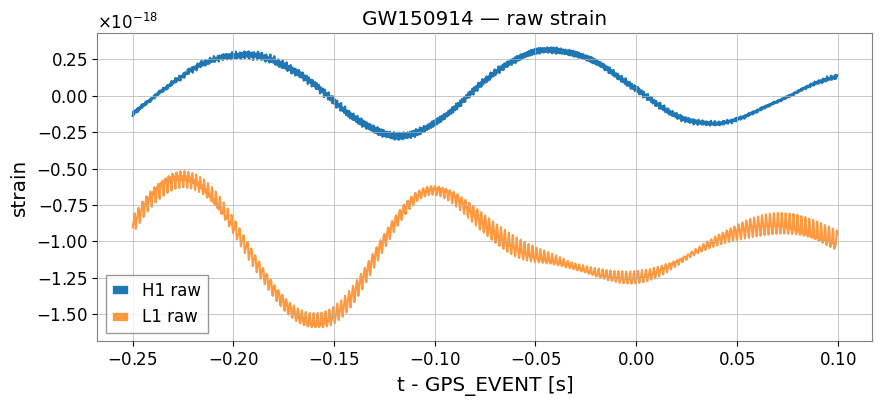

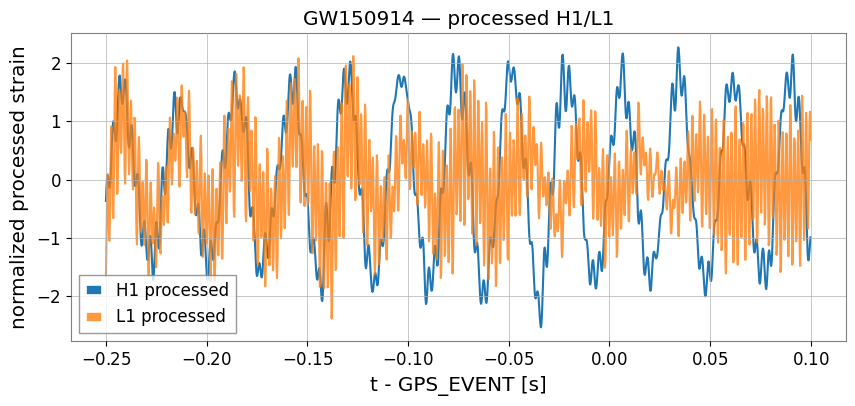

In [20]:

plt.figure(figsize=(10,4))
plt.plot(t_rel[event_mask], h1[event_mask], label="H1 raw")
plt.plot(t_rel[event_mask], l1[event_mask], label="L1 raw", alpha=0.8)
plt.xlabel("t - GPS_EVENT [s]")
plt.ylabel("strain")
plt.title("GW150914 — raw strain")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t_rel[event_mask], h1_z[event_mask], label="H1 processed")
plt.plot(t_rel[event_mask], l1_z[event_mask], label="L1 processed", alpha=0.8)
plt.xlabel("t - GPS_EVENT [s]")
plt.ylabel("normalized processed strain")
plt.title("GW150914 — processed H1/L1")
plt.legend()
plt.grid(True)
plt.show()



## 8. Mesure aveugle du retard H1/L1

Aucune valeur publiée du retard n'est injectée.

On calcule la corrélation croisée dans une fenêtre autour du chirp et on recherche le maximum en valeur absolue dans une plage causalement permise pour le baseline terrestre :

\[
|\tau|\le 12\ \mathrm{ms}.
\]

L'utilisation de \(|C|\) permet de ne pas imposer le signe relatif des réponses H1/L1.


In [22]:

TIMING_WINDOW = (-0.12, 0.04)
timing_mask = (t_rel >= TIMING_WINDOW[0]) & (t_rel <= TIMING_WINDOW[1])

x = h1_z[timing_mask]
y = l1_z[timing_mask]

x = x - np.mean(x)
y = y - np.mean(y)

corr = signal.correlate(x, y, mode="full", method="fft")
lags = signal.correlation_lags(len(x), len(y), mode="full") / fs

lag_search = np.abs(lags) <= 0.012
corr_search = corr[lag_search]
lags_search = lags[lag_search]

norm = np.linalg.norm(x) * np.linalg.norm(y)
corr_norm = corr_search / norm

i_best = int(np.argmax(np.abs(corr_norm)))
lag_best_s = float(lags_search[i_best])
corr_best = float(corr_norm[i_best])

TIMING_MEASURED = bool(
    np.isfinite(lag_best_s)
    and np.isfinite(corr_best)
    and abs(lag_best_s) <= 0.012
)

print("Measured lag H1 vs L1 [s] =", lag_best_s)
print("Measured |lag| [ms] =", abs(lag_best_s)*1e3)
print("Signed normalized correlation at best lag =", corr_best)
print("TIMING_MEASURED =", TIMING_MEASURED)
assert TIMING_MEASURED


Measured lag H1 vs L1 [s] = 0.006103515625
Measured |lag| [ms] = 6.103515625
Signed normalized correlation at best lag = -0.4901086700240681
TIMING_MEASURED = True


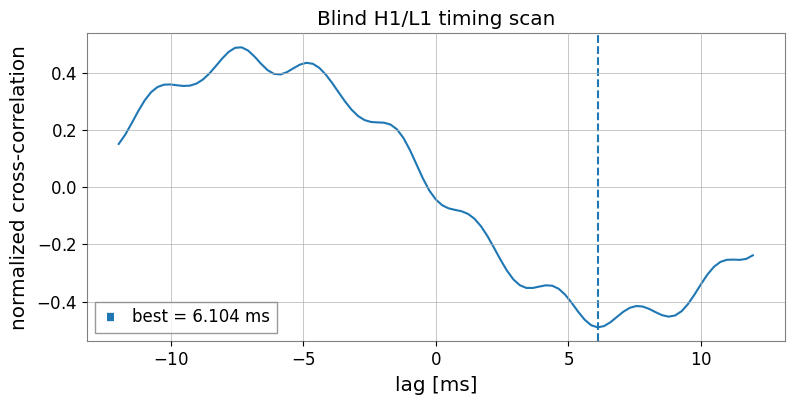

In [23]:

plt.figure(figsize=(9,4))
plt.plot(lags_search*1e3, corr_norm)
plt.axvline(lag_best_s*1e3, linestyle="--", label=f"best = {lag_best_s*1e3:.3f} ms")
plt.xlabel("lag [ms]")
plt.ylabel("normalized cross-correlation")
plt.title("Blind H1/L1 timing scan")
plt.grid(True)
plt.legend()
plt.show()



## 9. Contrôle de robustesse du retard par variation de fenêtre

Le retard est recalculé sur plusieurs fenêtres proches.  
On ne force pas le résultat à rester identique : la dispersion donne un diagnostic de stabilité.


In [24]:

timing_windows = [
    (-0.14, 0.04),
    (-0.12, 0.04),
    (-0.10, 0.04),
    (-0.12, 0.02),
    (-0.10, 0.02),
]

def estimate_lag(t0, t1, max_lag=0.012):
    m = (t_rel >= t0) & (t_rel <= t1)
    xx = h1_z[m] - np.mean(h1_z[m])
    yy = l1_z[m] - np.mean(l1_z[m])

    cc = signal.correlate(xx, yy, mode="full", method="fft")
    ll = signal.correlation_lags(len(xx), len(yy), mode="full") / fs

    keep = np.abs(ll) <= max_lag
    cc = cc[keep]
    ll = ll[keep]
    cc = cc / (np.linalg.norm(xx) * np.linalg.norm(yy))

    ib = np.argmax(np.abs(cc))
    return float(ll[ib]), float(cc[ib])

timing_rows = []
for w0, w1 in timing_windows:
    lag, cc = estimate_lag(w0, w1)
    timing_rows.append({
        "window_start_s": w0,
        "window_end_s": w1,
        "lag_ms": lag*1e3,
        "abs_lag_ms": abs(lag)*1e3,
        "corr": cc,
    })

timing_df = pd.DataFrame(timing_rows)
display(timing_df)

lag_median_ms = float(np.median(timing_df["lag_ms"]))
lag_mad_ms = float(np.median(np.abs(timing_df["lag_ms"] - lag_median_ms)))

print("median lag [ms] =", lag_median_ms)
print("MAD lag [ms] =", lag_mad_ms)


,window_start_s,window_end_s,lag_ms,abs_lag_ms,corr
0,-0.14,0.04,6.347656,6.347656,-0.490129
1,-0.12,0.04,6.103516,6.103516,-0.490109
2,-0.10,0.04,6.103516,6.103516,-0.511425
3,-0.12,0.02,-7.324219,7.324219,0.508044
4,-0.10,0.02,-7.324219,7.324219,0.506417


median lag [ms] = 6.103515625
MAD lag [ms] = 0.244140625



## 10. Alignement causal mesuré

On aligne L1 sur H1 avec **le retard mesuré par le notebook**, pas avec une valeur externe.

Pour un signal échantillonné :

\[
L1_{\rm aligned}(t)
=
L1(t-\widehat{\Delta t}_{HL})
\]

avec interpolation.


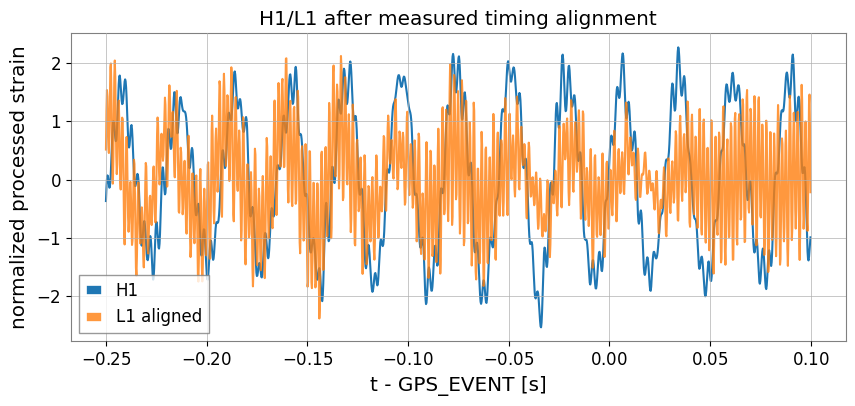

In [25]:

# Convention opérationnelle :
# corr(H1(t), L1(t+lag_best)) maximale => interpolation de L1 à t - lag_best.
l1_aligned = np.interp(
    t_rel,
    t_rel - lag_best_s,
    l1_z,
    left=np.nan,
    right=np.nan,
)

aligned_mask = event_mask & np.isfinite(l1_aligned)

plt.figure(figsize=(10,4))
plt.plot(t_rel[aligned_mask], h1_z[aligned_mask], label="H1")
plt.plot(t_rel[aligned_mask], l1_aligned[aligned_mask], label="L1 aligned", alpha=0.8)
plt.xlabel("t - GPS_EVENT [s]")
plt.ylabel("normalized processed strain")
plt.title("H1/L1 after measured timing alignment")
plt.grid(True)
plt.legend()
plt.show()



## 11. Observable de transition observationnelle

Dans cette version réelle, on calcule :

\[
D_{T,H1}^{\rm obs}(k)=
\left|\widetilde h_{H1,k+1}-\widetilde h_{H1,k}\right|,
\]

\[
D_{T,L1}^{\rm obs}(k)=
\left|\widetilde h_{L1,k+1}-\widetilde h_{L1,k}\right|.
\]

**On ne définit pas encore \(D_T^{\rm phys}\)** à partir de H1/L1 : les deux détecteurs sont des mesures bruitées.  
Une waveform GR/reconstruction indépendante sera requise pour définir ultérieurement \(D_T^{\rm ref}\).


,detector,mean_D_obs,median_D_obs,max_D_obs,sum_D_obs
0,H1,0.104513,0.093133,0.326186,149.767267
1,L1_aligned,0.406373,0.387232,1.107781,582.332976


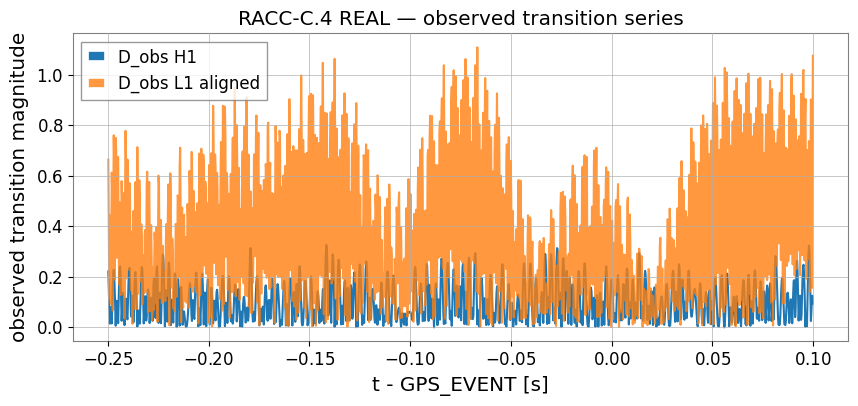

In [26]:

def D_transition(z):
    z = np.asarray(z, float)
    return np.abs(np.diff(z))

h1_ev = h1_z[aligned_mask]
l1_ev = l1_aligned[aligned_mask]
t_ev = t_rel[aligned_mask]

D_H1 = D_transition(h1_ev)
D_L1 = D_transition(l1_ev)
t_D = t_ev[1:]

transition_summary = pd.DataFrame([
    {
        "detector": "H1",
        "mean_D_obs": float(np.mean(D_H1)),
        "median_D_obs": float(np.median(D_H1)),
        "max_D_obs": float(np.max(D_H1)),
        "sum_D_obs": float(np.sum(D_H1)),
    },
    {
        "detector": "L1_aligned",
        "mean_D_obs": float(np.mean(D_L1)),
        "median_D_obs": float(np.median(D_L1)),
        "max_D_obs": float(np.max(D_L1)),
        "sum_D_obs": float(np.sum(D_L1)),
    },
])
display(transition_summary)

plt.figure(figsize=(10,4))
plt.plot(t_D, D_H1, label="D_obs H1")
plt.plot(t_D, D_L1, label="D_obs L1 aligned", alpha=0.8)
plt.xlabel("t - GPS_EVENT [s]")
plt.ylabel("observed transition magnitude")
plt.title("RACC-C.4 REAL — observed transition series")
plt.grid(True)
plt.legend()
plt.show()



## 12. Contrôle hors événement

Le même \(D_T^{\rm obs}\) est calculé dans une fenêtre sans événement afin de comparer l'activité transitionnelle du chirp au bruit.


In [27]:

CONTROL_WINDOW = (-8.0, -7.65)
control_mask = (t_rel >= CONTROL_WINDOW[0]) & (t_rel <= CONTROL_WINDOW[1])

h1_ctrl = h1_z[control_mask]
l1_ctrl = l1_z[control_mask]

D_H1_ctrl = D_transition(h1_ctrl)
D_L1_ctrl = D_transition(l1_ctrl)

control_summary = pd.DataFrame([
    {
        "detector":"H1",
        "event_mean_D":float(np.mean(D_H1)),
        "control_mean_D":float(np.mean(D_H1_ctrl)),
        "event_max_D":float(np.max(D_H1)),
        "control_max_D":float(np.max(D_H1_ctrl)),
    },
    {
        "detector":"L1",
        "event_mean_D":float(np.mean(D_L1)),
        "control_mean_D":float(np.mean(D_L1_ctrl)),
        "event_max_D":float(np.max(D_L1)),
        "control_max_D":float(np.max(D_L1_ctrl)),
    },
])
display(control_summary)


,detector,event_mean_D,control_mean_D,event_max_D,control_max_D
0,H1,0.104513,0.098793,0.326186,0.354632
1,L1,0.406373,0.363694,1.107781,1.057438



## 13. Verdict automatique

Cette première version réelle ne teste **pas** une correction GVH.

Elle vérifie seulement que :

- les données réelles sont lisibles et cohérentes ;
- H1/L1 ont même fenêtre et cadence ;
- le prétraitement est fini ;
- un retard H1/L1 est mesuré sans valeur injectée ;
- les séries \(D_T^{\rm obs}\) sont calculables après alignement.

Le verdict `REAL-OBS-READY` signifie uniquement que la couche observationnelle réelle est prête pour une comparaison standard plus complète.


In [33]:

GATES = {
    "REAL_DATA_INTEGRITY": bool(REAL_DATA_INTEGRITY),
    "DATA_QUALITY": bool(DATA_QUALITY),
    "PREPROCESSING_FINITE": bool(PREPROCESSING_FINITE),
    "TIMING_MEASURED": bool(TIMING_MEASURED),
    "SAME_SAMPLE_RATE": bool(SAME_SAMPLE_RATE),
    "EXPECTED_SAMPLE_RATE": bool(EXPECTED_SAMPLE_RATE),
    "EXPECTED_LENGTH": bool(EXPECTED_LENGTH),
    "SAME_GPS_START": bool(SAME_GPS_START),
}

FINAL_STATUS = "REAL-OBS-READY" if all(GATES.values()) else "UNRESOLVED"

artifact = {
    "notebook": "GVH_Diagonal_Cubic_RACC_C4_REAL_GW150914_H1_L1",
    "scientific_role": "real_observation_interface_validation",
    "core_GVH_modified": False,
    "event": "GW150914",
    "gps_event_reference": GPS_EVENT,
    "h1_file": H1_FILE.name,
    "l1_file": L1_FILE.name,
    "gates": GATES,
    "measured_lag_s": lag_best_s,
    "measured_lag_ms": lag_best_s * 1e3,
    "measured_abs_lag_ms": abs(lag_best_s) * 1e3,
    "timing_window_robustness": timing_df.to_dict(orient="records"),
    "transition_summary": transition_summary.to_dict(orient="records"),
    "control_summary": control_summary.to_dict(orient="records"),
    "D_phys_defined": False,
    "D_ref_required_next": True,
    "final_status": FINAL_STATUS,
}

print(json.dumps(artifact, indent=2))
assert FINAL_STATUS == "REAL-OBS-READY"


{
  "notebook": "GVH_Diagonal_Cubic_RACC_C4_REAL_GW150914_H1_L1",
  "scientific_role": "real_observation_interface_validation",
  "core_GVH_modified": false,
  "event": "GW150914",
  "gps_event_reference": 1126259462.0,
  "h1_file": "H-H1_LOSC_4_V2-1126259446-32 2.gwf",
  "l1_file": "L-L1_LOSC_4_V2-1126259446-32.gwf",
  "gates": {
    "REAL_DATA_INTEGRITY": true,
    "DATA_QUALITY": true,
    "PREPROCESSING_FINITE": true,
    "TIMING_MEASURED": true,
    "SAME_SAMPLE_RATE": true,
    "EXPECTED_SAMPLE_RATE": true,
    "EXPECTED_LENGTH": true,
    "SAME_GPS_START": true
  },
  "measured_lag_s": 0.006103515625,
  "measured_lag_ms": 6.103515625,
  "measured_abs_lag_ms": 6.103515625,
  "timing_window_robustness": [
    {
      "window_start_s": -0.14,
      "window_end_s": 0.04,
      "lag_ms": 6.34765625,
      "abs_lag_ms": 6.34765625,
      "corr": -0.4901285744977588
    },
    {
      "window_start_s": -0.12,
      "window_end_s": 0.04,
      "lag_ms": 6.103515625,
      "abs_lag_ms": 


## 14. Interprétation autorisée

Si `REAL-OBS-READY` :

\[
\boxed{
\text{données réelles}
\rightarrow
\text{prétraitement}
\rightarrow
\widehat{\Delta t}_{HL}
\rightarrow
D_{T,H1}^{\rm obs},D_{T,L1}^{\rm obs}
}
\]

est techniquement opérationnel.

### Ce qui n'est PAS encore autorisé

- appeler un écart H1/L1 une signature GVH ;
- définir \(D_T^{\rm phys}\) comme \(H1+L1\) ou leur moyenne brute ;
- fermer un gate Hamiltonien/Dirac/HH ;
- changer `DISPERSION_READY`.

### Étape suivante

Construire une référence indépendante :

\[
h_{\rm GR/ref}(t)
\rightarrow
D_T^{\rm ref}
\]

puis comparer :

\[
D_T^{\rm ref},
\qquad
D_{T,H1}^{\rm obs},
\qquad
D_{T,L1}^{\rm obs}.
\]

Cette extension doit rester séparée du noyau GVH Diagonal.
